Ridge Regression Results:
Best Alpha: 10.0
Training MSE: 0.5205625806008584
Test MSE: 0.5408268817888305

Lasso Regression Results:
Best Alpha: 0.0035564803062231283
Training MSE: 0.5212500320388265
Test MSE: 0.5376180459838826

Training and Test MSE are very similar for Lasso and Ridge, however, Test MSE is slightly smaller for Lasso, indicating that Lasso performs a bit better on new data.

Coefficient Comparison:
            Ridge Coefficients  Lasso Coefficients
MedInc                0.851446            0.832968
HouseAge              0.121473            0.122568
AveRooms             -0.299816           -0.254004
AveBedrms             0.345789            0.300113
Population           -0.001376           -0.000000
AveOccup             -0.041202           -0.037565
Latitude             -0.885227           -0.855313
Longitude            -0.859804           -0.827395

Lasso shrank Population Coefficient to 0. All the other coefficients generally reduced with Lasso, except for the HouseA

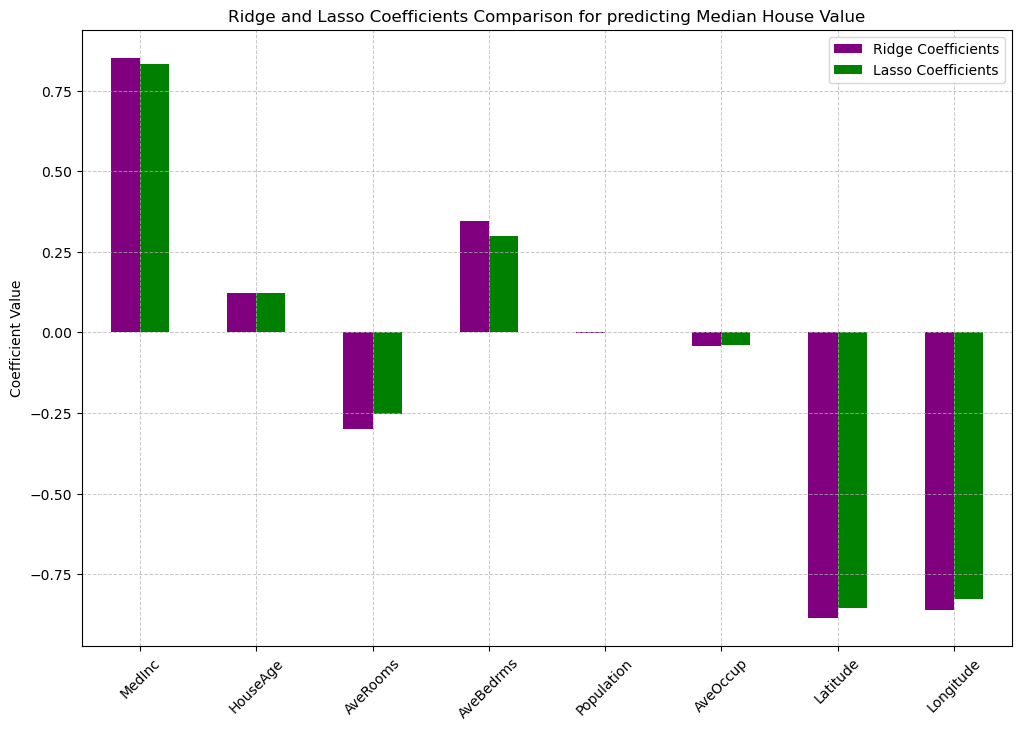

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the California Housing dataset
data_cal_hp = fetch_california_housing(as_frame=True)      # Data returned as a Pandas DataFrame
X = data_cal_hp.data                                       # Extract the features (predictors) from the data set and store them in X
y = data_cal_hp.target                                     # The target variable is the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000)
#data.frame.info()                                         # <-- Uncomment this command and see that there are no Null Values in the Dataset (Features), which helps in our analysis

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)     # Use 75% of the data for training, and 25% for testing. Also set a seed (random_state=42)

# Standardize the features
scaler = StandardScaler()                                  # Remove the mean and scale to unit variance, so each feature will have a mean of 0 and a standard deviation of 1
X_train = scaler.fit_transform(X_train)                    # Apply the standardization to X_train
X_test = scaler.transform(X_test)                          # Apply scaling transformation to X_test, using the mean and standard deviation calculated from X_train, so that X_test and X_train are on the same scale

# Apply Ridge Regression with cross-validation to find the best alpha
ridge_model = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)                     # Create a Ridge regression model with cv=5 to find the best regularization parameter (alpha)
ridge_model.fit(X_train, y_train)                                              # Fit the model to the training data and perform cross-validation to select the optimal alpha
ridge_train_mse = mean_squared_error(y_train, ridge_model.predict(X_train))    # Calculate the training MSE of the fitted Ridge model
ridge_test_mse = mean_squared_error(y_test, ridge_model.predict(X_test))       # Calculate the test MSE as well
ridge_best_alpha = ridge_model.alpha_                                          # Retrieve the best alpha value found during cross-validation

# Apply Lasso Regression with cross-validation to find the best alpha
#lasso_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5)                    # <-- First used logspace(-6, 6, 13) and got λ = 0.001, but decided to be more strict
lasso_model = LassoCV(alphas=np.logspace(-8, 8, 50), cv=5)                     # After some testing, I used logspace(-8, 8, 50). Now I got λ ~= 0.003556, which is more strict, but with smaller test MSE
lasso_model.fit(X_train, y_train)
lasso_train_mse = mean_squared_error(y_train, lasso_model.predict(X_train))
lasso_test_mse = mean_squared_error(y_test, lasso_model.predict(X_test))
lasso_best_alpha = lasso_model.alpha_                                               

# Report the best alpha(α) and mean squared error(MSE) on both the training and test sets
print("Ridge Regression Results:")
print(f"Best Alpha: {ridge_best_alpha}")
print(f"Training MSE: {ridge_train_mse}")
print(f"Test MSE: {ridge_test_mse}")

print("\nLasso Regression Results:")
print(f"Best Alpha: {lasso_best_alpha}")
print(f"Training MSE: {lasso_train_mse}")
print(f"Test MSE: {lasso_test_mse}")

print("\nTraining and Test MSE are very similar for Lasso and Ridge, however, Test MSE is slightly smaller for Lasso, indicating that Lasso performs a bit better on new data.")

# Coefficients comparison between Ridge and Lasso
ridge_coefs = pd.Series(ridge_model.coef_, index=data_cal_hp.feature_names)      # Store the coefficients in pandas series, and index them accordingly to each feature (at this case for Ridge)
lasso_coefs = pd.Series(lasso_model.coef_, index=data_cal_hp.feature_names)

coefs_df = pd.DataFrame({                 
    'Ridge Coefficients': ridge_coefs,                                           # Create a Pd DataFrame named coefs_df, to organizes the Ridge and Lasso model coefficients for better visualization, when we print
    'Lasso Coefficients': lasso_coefs
})

print("\nCoefficient Comparison:")
print(coefs_df)

print("\nLasso shrank Population Coefficient to 0. All the other coefficients generally reduced with Lasso, except for the HouseAge which is slightly smaller for Ridge.")
      
# Plot the coefficients to compare their values for Ridge and Lasso regression
fig, ax = plt.subplots(figsize=(12, 8))
coefs_df.plot(kind='bar', ax=ax, color=["purple", "green"])  
plt.title("Ridge and Lasso Coefficients Comparison for predicting Median House Value")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)            # Add grid lines for better visualization
plt.show()